# Optimizing Bike Distribution in Mexico City: An Analysis of Ecobici Trip Data

## Introduction

ECOBICI is Mexico City's public bike-sharing system, operating as an integral part of the city's multimodal transportation network. With over 677 stations and thousands of registered users, the system allows subscribers to pick up a bike at any station, make unlimited trips of up to 45 minutes, and return it to any station within the network.

One of the core operational challenges of any bike-sharing system is bike redistribution: ensuring that bikes are available where and when users need them. Demand fluctuates based on time of day, day of the week, and station location — meaning that some stations regularly run out of bikes while others accumulate excess inventory.

This case study analyzes six months of historical ECOBICI trip data (September 2025 – February 2026) to identify demand patterns across stations and time periods. The goal is to generate actionable insights that can support smarter, data-driven redistribution strategies.

## How can ECOBICI optimize bicycle distribution across stations based on trip demand patterns?

ECOBICI must ensure that bikes are available at stations when users need them. However, demand fluctuates depending on time, location, and day of the week. Understanding these patterns can help improve bike redistribution strategies.

In order to answer the main question, there's some things we have to consider:

 - Which stations have the highest demand?
 - At what times of day and days of the week is usage highest?
 - Which routes are most frequently used?
 - Which stations experience the highest arrival or departure imbalance?

## Stakeholders

The insights generated from this analysis are intended to support decision-making across several areas:

 - **ECOBICI operations team**: to design more efficient bike redistribution schedules based on demand peaks and station imbalance patterns.
 - **City mobility planners**: to understand how the system integrates with broader urban mobility flows and identify underserved areas or expansion opportunities.
 - **System administrators**: to anticipate high-demand periods and proactively rebalance inventory before shortages occur.

## Dataset

The dataset used in this analysis was obtained from the official ECOBICI website, which provides public historical records of bike trips within the system.

For this case study, trip data from **September 2025 to February 2026** was selected to analyze recent usage patterns.

### Trip data

- 6 monthly CSV files
- Total: approximately **9.4 million individual trips**
- Main variables:
  - User gender
  - User age
  - Bicycle ID
  - Departure station (ID), name, municipality and suburb
  - Departure date and time
  - Arrival station (ID), name, municipality and suburb
  - Arrival date and time

### Stations metadata

To enrich the trip data with spatial context, station metadata was collected separately via the official GBFS API (`https://gbfs.mex.lyftbikes.com/gbfs/gbfs.json`).

This metadata — including station name, municipality (alcaldía), neighborhood (colonia), and dock capacity for 677 stations — was merged with each monthly trip file using station IDs in a separate preprocessing step (see ***merge_ecobici_stations_info.py*** and ***stations.py*** for the full merging pipeline)

The monthly files loaded in this notebook already include these enriched variables, enabling spatial analysis of demand patterns and station-level imbalance directly from the raw files.

## Data loading

The six monthly CSV files are loaded from the dataset directory and concatenated 
into a single DataFrame for unified processing.

In [1]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
## Load and concatenate

path = "/kaggle/input/datasets/andyyyg/ecobici-trips-dataset-092025-to-022026"
files = sorted([f for f in os.listdir(path) if f.endswith(".csv")])

dfs = []
for file in files:
    df = pd.read_csv(os.path.join(path, file))
    print(f"File read: {file} — Rows: {len(df):,}")
    dfs.append(df)

ecobici_trips = pd.concat(dfs, ignore_index=True)
print(f"\nTotal trips loaded: {len(ecobici_trips):,}")

File read: 2025-09.csv — Rows: 1,586,508
File read: 2025-10.csv — Rows: 1,754,353
File read: 2025-11.csv — Rows: 1,600,741
File read: 2025-12.csv — Rows: 1,445,068
File read: 2026-01.csv — Rows: 1,525,302
File read: 2026-02.csv — Rows: 1,528,610

Total trips loaded: 9,440,582


## Data cleaning

The six monthly files are concatenated into a single DataFrame and prepared for analysis. 

This section covers: 

    - Type conversion
    - Column selection 
    - Missing value inspection
    - Removal of invalid records.

In [3]:
## Initial inspection

ecobici_trips = pd.concat(dfs, ignore_index=True)

print(f"Total trips: {len(ecobici_trips):,}")
print(f"\nShape: {ecobici_trips.shape}")
ecobici_trips.info()

Total trips: 9,440,582

Shape: (9440582, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440582 entries, 0 to 9440581
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   user_gender             object 
 1   user_age                float64
 2   bike_id                 int64  
 3   departure_station_id    object 
 4   departure_date          object 
 5   departure_time          object 
 6   arrival_station_id      object 
 7   arrival_date            object 
 8   arrival_time            object 
 9   departure_station_name  object 
 10  departure_municipality  object 
 11  departure_suburb        object 
 12  arrival_station_name    object 
 13  arrival_municipality    object 
 14  arrival_suburb          object 
dtypes: float64(1), int64(1), object(13)
memory usage: 1.1+ GB


Many columns are stored as strings (`object`) even though they are dates, times or IDs.  
We convert them to the appropriate types for efficient analysis and calculations.

In [4]:
# Convert dates + hours to datetime
ecobici_trips['departure_datetime'] = pd.to_datetime(
    ecobici_trips['departure_date'] + ' ' + ecobici_trips['departure_time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

ecobici_trips['arrival_datetime'] = pd.to_datetime(
    ecobici_trips['arrival_date'] + ' ' + ecobici_trips['arrival_time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Calculate duration in minutes
ecobici_trips['trip_duration_min'] = (ecobici_trips['arrival_datetime'] - ecobici_trips['departure_datetime']).dt.total_seconds() / 60

In [5]:
ecobici_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440582 entries, 0 to 9440581
Data columns (total 18 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   user_gender             object        
 1   user_age                float64       
 2   bike_id                 int64         
 3   departure_station_id    object        
 4   departure_date          object        
 5   departure_time          object        
 6   arrival_station_id      object        
 7   arrival_date            object        
 8   arrival_time            object        
 9   departure_station_name  object        
 10  departure_municipality  object        
 11  departure_suburb        object        
 12  arrival_station_name    object        
 13  arrival_municipality    object        
 14  arrival_suburb          object        
 15  departure_datetime      datetime64[ns]
 16  arrival_datetime        datetime64[ns]
 17  trip_duration_min       float64       
dtypes:

As we only need a subset of columns for the analysis, we create a new, more efficient dataframe with only the relevant features.

This reduces memory usage and makes subsequent operations faster and cleaner.

In [6]:
new_columns = [
    'bike_id',
    'departure_station_id',
    'departure_station_name',
    'departure_municipality',
    'departure_suburb',
    'departure_datetime',
    'arrival_station_id',
    'arrival_station_name',
    'arrival_municipality',
    'arrival_suburb',
    'arrival_datetime',
    'trip_duration_min'
]

ecobici_trips2 = ecobici_trips[new_columns].copy()

In [7]:
ecobici_trips2.info()
print()
ecobici_trips2.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9440582 entries, 0 to 9440581
Data columns (total 12 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   bike_id                 int64         
 1   departure_station_id    object        
 2   departure_station_name  object        
 3   departure_municipality  object        
 4   departure_suburb        object        
 5   departure_datetime      datetime64[ns]
 6   arrival_station_id      object        
 7   arrival_station_name    object        
 8   arrival_municipality    object        
 9   arrival_suburb          object        
 10  arrival_datetime        datetime64[ns]
 11  trip_duration_min       float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(8)
memory usage: 864.3+ MB



,bike_id,departure_station_id,departure_station_name,departure_municipality,departure_suburb,departure_datetime,arrival_station_id,arrival_station_name,arrival_municipality,arrival_suburb,arrival_datetime,trip_duration_min
0,3584745,038,CE-038 Cozumel - Puebla,Cuauhtémoc,Roma Norte,2025-08-31 23:23:31,612,CE-612 Torres Adalid - Cumbres de Maltrata,Benito Juárez,Narvarte Oriente,2025-09-01 00:00:18,36.783333
1,7377708,339,CE-339 Enrique Rébsamen-Avenida Eugenia,Benito Juárez,Narvarte Poniente,2025-08-31 23:45:46,635,CE-635 Calzada Santa Cruz - Antillas,Benito Juárez,Portales Norte,2025-09-01 00:00:25,14.650000
2,5449988,593,CE-593 Zempoala - Diagonal de San Antonio,Benito Juárez,Narvarte Oriente,2025-08-31 23:45:59,573,CE-573 Fernando Ramírez - Isabel la Católica,Cuauhtémoc,Obrera,2025-09-01 00:00:36,14.616667
3,6596803,412,CE-412 Parroquia-Avenida Universidad,Benito Juárez,Santa Cruz Atoyac,2025-08-31 23:51:38,624,CE-624 Luis Spota - Eje Central Lázaro Cárdenas,Benito Juárez,San Simon Ticumac,2025-09-01 00:00:38,9.000000
4,3795499,565,CE-565 Dr. Martinez del Rio - Dr. Lucio,Cuauhtémoc,Doctores,2025-08-31 23:54:26,163,CE-163 Toluca-Bajío,Cuauhtémoc,Roma Sur,2025-09-01 00:00:44,6.300000


Finally, before proceeding with the analysis, we check for missing values and invalid data in key columns.

There is four types of invalid data:

- **Zero or negative trip duration**: these trips have no valid origin-destination information and are removed as data entry errors.
- **Trips under 2 minutes**: likely represent cancellations or accidental checkouts. Additionally, round trips (same departure and arrival station) under 5 minutes are removed, as these almost certainly reflect user errors rather than intentional travel.
- **Trips over 60 minutes**: while ECOBICI charges extra for trips exceeding 45 minutes, a 60-minute ceiling is applied to exclude likely errors such as improper bike docking, forgotten returns, or theft. Trips in this range represent edge cases with limited analytical value.
- **Trips outside the desired date range**: trips that fall outside the target period (September 2025 to February 2026).

All these filters ensure the dataset reflects realistic user mobility patterns and improves the quality of insights about demand and redistribution needs.

In [8]:
# Check for missing values in critical columns
print("Missing values in key columns:")
missing = ecobici_trips2[['departure_station_id', 'arrival_station_id',
                          'departure_station_name', 'arrival_station_name',
                          'departure_datetime', 'arrival_datetime',
                          'trip_duration_min','departure_municipality','arrival_municipality','departure_suburb','arrival_suburb']].isna().sum()
print(missing)

# Count of round trips under 5 minutes = likely user error
round_trip_error = (
    (ecobici_trips2['departure_station_id'] == ecobici_trips2['arrival_station_id']) &
    (ecobici_trips2['trip_duration_min'] < 5)
)

print(f"Round trips under 5 minutes:  {round_trip_error.sum():,}")

# Trips with zero or negative duration
invalid_duration = (ecobici_trips2['trip_duration_min'] <= 0 )

print(f"Trips with zero or negative durantions:  {invalid_duration.sum():,}")

# Trips under 2 minutes regardless of station = likely error or cancellation
invalid_duration_less2 = (ecobici_trips2['trip_duration_min'] <= 2 )

print(f"Trips under 2 minutes durantions:  {invalid_duration_less2.sum():,}")

# Trips above 1 hour 
invalid_duration_hour = (ecobici_trips2['trip_duration_min'] > 60 )

print(f"Trips above 1 hour:  {invalid_duration_hour.sum():,}")

# Trips with invalid date range
start_valid = pd.to_datetime('2025-09-01 00:00:00')
end_valid   = pd.to_datetime('2026-02-28 23:59:59')

invalid_range = (ecobici_trips2['departure_datetime'] < start_valid) | \
                     (ecobici_trips2['departure_datetime'] > end_valid)

print(f"Trips with invalid dates: {invalid_range.sum():,}")

# Few examples of problematic rows
print("\nExamples of rows with problems:")
display(ecobici_trips2[ecobici_trips2['departure_station_name'].isna()].head())

Missing values in key columns:
departure_station_id        0
arrival_station_id          0
departure_station_name     72
arrival_station_name      218
departure_datetime          0
arrival_datetime            0
trip_duration_min           0
departure_municipality     72
arrival_municipality      218
departure_suburb           72
arrival_suburb            218
dtype: int64
Round trips under 5 minutes:  30,039
Trips with zero or negative durantions:  0
Trips under 2 minutes durantions:  53,739
Trips above 1 hour:  53,543
Trips with invalid dates: 130

Examples of rows with problems:


,bike_id,departure_station_id,departure_station_name,departure_municipality,departure_suburb,departure_datetime,arrival_station_id,arrival_station_name,arrival_municipality,arrival_suburb,arrival_datetime,trip_duration_min
1315134,7730161,1000,NaN,NaN,NaN,2025-09-25 18:13:17,254,CE-254 Alfonso Herrera-Miguel Shultz,Cuauhtémoc,San Rafael,2025-09-25 18:30:43,17.433333
1638869,6101620,1000,NaN,NaN,NaN,2025-10-01 18:29:23,124,CE-124 Claudio Bernard-Dr. Liceaga,Cuauhtémoc,Doctores,2025-10-01 18:54:53,25.500000
1702524,2188290,1000,NaN,NaN,NaN,2025-10-02 18:16:29,260,CE-260 Av. Juárez-Balderas,Cuauhtémoc,Centro,2025-10-02 18:37:14,20.750000
1767870,3901626,1000,NaN,NaN,NaN,2025-10-03 18:21:28,260,CE-260 Av. Juárez-Balderas,Cuauhtémoc,Centro,2025-10-03 18:47:41,26.216667
1896530,4854667,1000,NaN,NaN,NaN,2025-10-06 18:33:48,588,CE-588 Av. Fernando - La coruña,Benito Juárez,Alamos,2025-10-06 19:15:14,41.433333


As we can notice in the examples provided, there's a pattern where the only rows with missing values (in station name, municipality, and suburb) are the ones where the station ID, either in departure or arrival, is equal to '1000'.

To confirm this observation, we perform a quick check:

In [9]:
trips_departure_1000 = (ecobici_trips2['departure_station_id']) == '1000'
trips_arrival_1000 = (ecobici_trips2['arrival_station_id'] == '1000')

print(f"Trips with departure station id '1000' : {trips_departure_1000.sum()}")
print(f"Trips with arrival station id '1000' : {trips_arrival_1000.sum()}")

Trips with departure station id '1000' : 72
Trips with arrival station id '1000' : 218


This confirms that all missing station metadata corresponds exclusively to ID '1000', which does not appear in the official ECOBICI station list (likely a system error, internal code, or data anomaly).

Given that these rows represent only ~0.003% of the total dataset and do not correspond to real, usable stations, we remove them entirely. This step is performed together with filtering out invalid trip durations to ensure the final dataset is clean and reliable for analysis.

In [10]:
# Remove rows where departure or arrival station ID is '1000'
invalid_id = ((ecobici_trips2['departure_station_id'] == '1000') | 
                  (ecobici_trips2['arrival_station_id'] == '1000'))

invalid_mask = invalid_id | round_trip_error | invalid_duration | invalid_duration_less2 | invalid_duration_hour | invalid_range

ecobici_clean = ecobici_trips2[~invalid_mask].copy()

print(f"Trips before removing missing values and invalid durations: {len(ecobici_trips2):,}")
print(f"Trips after removing: {len(ecobici_clean):,}")
print(f"Removed: {invalid_mask.sum():,}")
print(f"Percentage removed: {invalid_mask.mean()*100:.4f}%")

Trips before removing missing values and invalid durations: 9,440,582
Trips after removing: 9,303,288
Removed: 137,294
Percentage removed: 1.4543%


## Exploratory Data Analysis

### 1. Overview

Before diving into specific patterns, we take a high-level look at the dataset to understand its overall shape: how trips are distributed across months, what the typical trip duration looks like, and basic descriptive statistics.

In [11]:
## Monthly volume

ecobici_clean['month'] = ecobici_clean['departure_datetime'].dt.to_period('M')

monthly = (ecobici_clean
           .groupby('month')
           .size()
           .reset_index(name='total_trips'))

print(monthly.to_string(index=False))

  month  total_trips
2025-09      1563708
2025-10      1729445
2025-11      1576799
2025-12      1423751
2026-01      1503614
2026-02      1505971


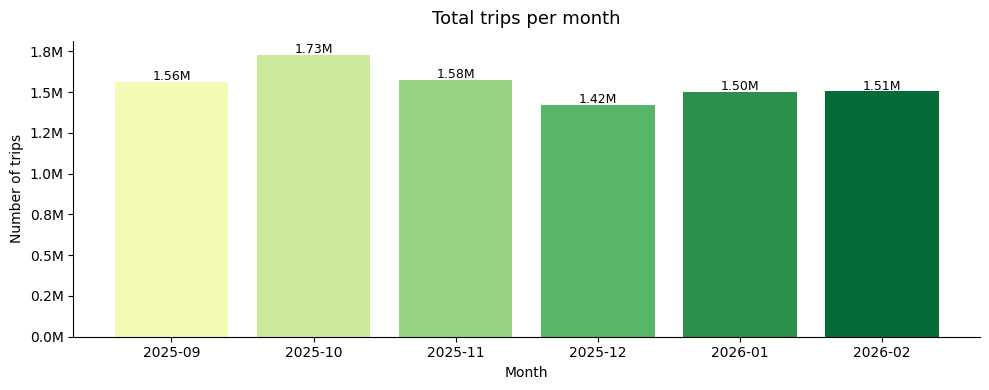

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(monthly['month'].astype(str), 
       monthly['total_trips'],
       color=sns.color_palette('YlGn', len(monthly)))

ax.set_title('Total trips per month', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of trips')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for i, row in monthly.iterrows():
    ax.text(i, row['total_trips'] + 10000, 
            f"{row['total_trips']/1e6:.2f}M", 
            ha='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

The distribution of trip durations reveals how users interact with the system.

Trips are capped at 60 minutes in the cleaned dataset: the 45-minute no-extra-charge-use threshold discourages longer trips due to extra charges, and trips beyond 60 minutes are considered likely errors rather than intentional travel.

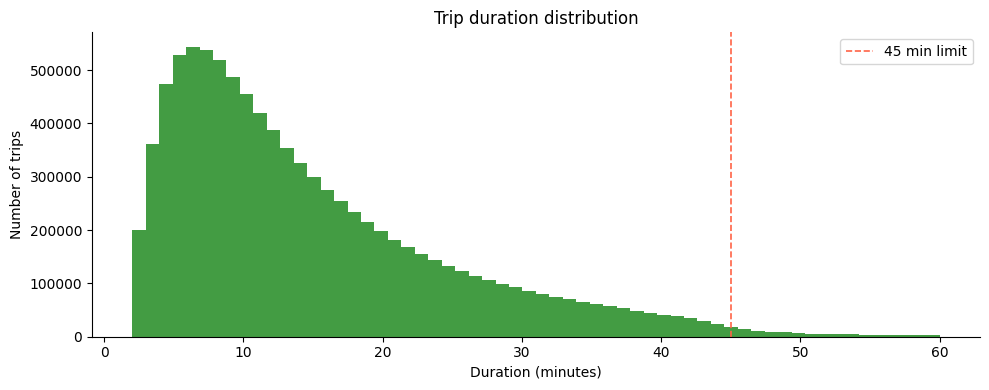

In [13]:
## Duration distribution

fig, axes = plt.subplots(figsize=(10, 4))

# Histogram 
axes.hist(ecobici_clean['trip_duration_min'],
             bins=60, color='forestgreen', edgecolor='none', alpha=0.85)
axes.axvline(45, color='tomato', linestyle='--', linewidth=1.2, label='45 min limit')
axes.set_title('Trip duration distribution', fontsize=12)
axes.set_xlabel('Duration (minutes)')
axes.set_ylabel('Number of trips')
axes.legend()

sns.despine()
plt.tight_layout()
plt.show()

### 2. Temporal Patterns

Understanding when trips occur is essential for planning redistribution schedules.

This section examines demand by hour of day, day of week, and the contrast between weekday and weekend behavior.

In [14]:
## Feature extraction

ecobici_clean['hour']       = ecobici_clean['departure_datetime'].dt.hour
ecobici_clean['day_of_week']= ecobici_clean['departure_datetime'].dt.dayofweek  # 0=Mon, 6=Sun
ecobici_clean['day_name']   = ecobici_clean['departure_datetime'].dt.day_name()
ecobici_clean['is_weekend']  = ecobici_clean['day_of_week'].isin([5, 6])

#### Trips by hour of day

Aggregating departures by hour reveals when demand peaks throughout the day.

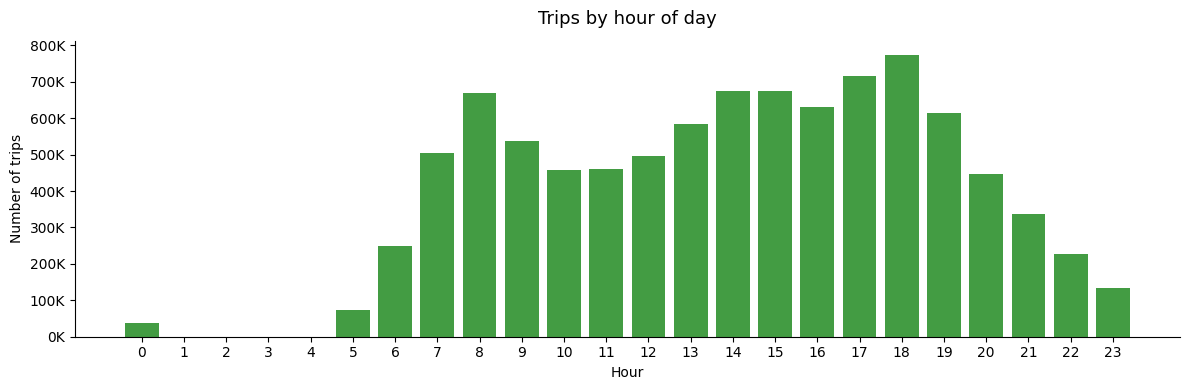

In [15]:
## Trips by hour

hourly = (ecobici_clean
          .groupby('hour')
          .size()
          .reset_index(name='total_trips'))

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(hourly['hour'], hourly['total_trips'],
       color='forestgreen', edgecolor='none', alpha=0.85)

ax.set_title('Trips by hour of day', fontsize=13, pad=12)
ax.set_xlabel('Hour')
ax.set_ylabel('Number of trips')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

sns.despine()
plt.tight_layout()
plt.show()

#### Weekday vs weekend demand

User behavior differs significantly between working days and weekends. 

Weekday trips tend to follow commuter patterns, while weekend trips are more evenly distributed throughout the day.

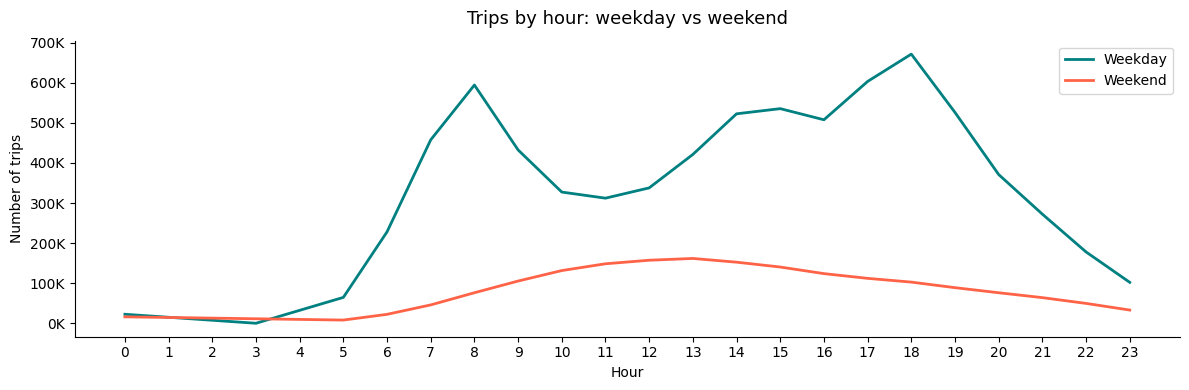

In [16]:
## Weekday vs weekend by hour

hourly_type = (ecobici_clean
               .groupby(['hour', 'is_weekend'])
               .size()
               .reset_index(name='total_trips'))

hourly_type['day_type'] = hourly_type['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

fig, ax = plt.subplots(figsize=(12, 4))

for day_type, color in [('Weekday', 'teal'), ('Weekend', 'tomato')]:
    subset = hourly_type[hourly_type['day_type'] == day_type]
    ax.plot(subset['hour'], subset['total_trips'],
            label=day_type, color=color, linewidth=2)

ax.set_title('Trips by hour: weekday vs weekend', fontsize=13, pad=12)
ax.set_xlabel('Hour')
ax.set_ylabel('Number of trips')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

#### Trips by day of week

Looking at total demand across days of the week shows whether usage is concentrated on working days or distributed more evenly.

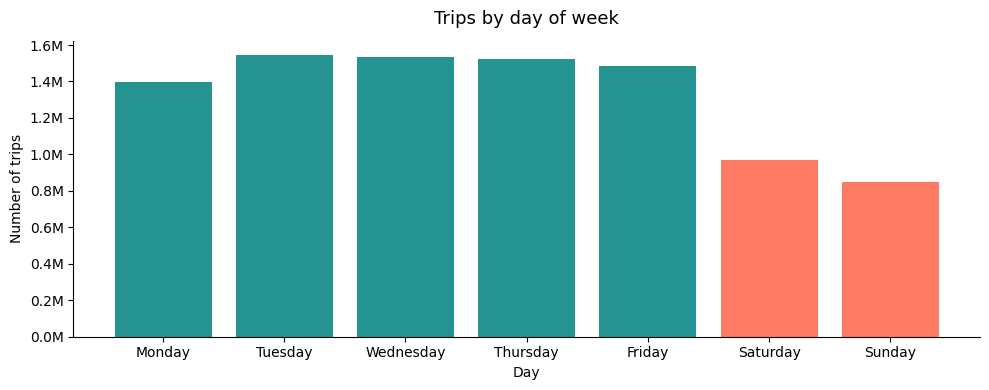

In [17]:
## Trips by day of week

day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = (ecobici_clean
         .groupby('day_name')
         .size()
         .reindex(day_order)
         .reset_index(name='total_trips'))

colors = ['teal' if d not in ['Saturday', 'Sunday'] else 'tomato' for d in day_order]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(daily['day_name'], daily['total_trips'],
       color=colors, edgecolor='none', alpha=0.85)

ax.set_title('Trips by day of week', fontsize=13, pad=12)
ax.set_xlabel('Day')
ax.set_ylabel('Number of trips')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

sns.despine()
plt.tight_layout()
plt.show()

#### Demand heatmap

The heatmap below combines hour and day of week into a single view, making it easy to spot the highest demand time slots at a glance.

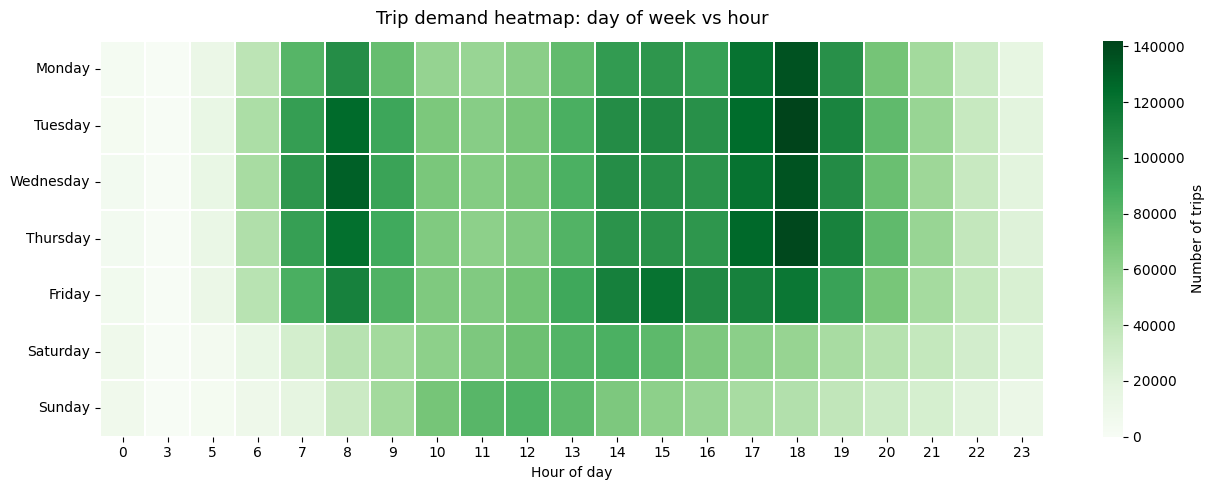

In [18]:
heatmap_data = (ecobici_clean
                .groupby(['day_of_week', 'hour'])
                .size()
                .unstack(fill_value=0))

heatmap_data.index = day_order

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(heatmap_data,
            cmap='Greens',
            linewidths=0.3,
            linecolor='white',
            fmt=',',
            ax=ax,
            cbar_kws={'label': 'Number of trips'})

ax.set_title('Trip demand heatmap: day of week vs hour', fontsize=13, pad=12)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

### 3. Station Demand

This section identifies which stations and municipalities concentrate the highest departure and arrival demand across the six-month period.

#### Top departure stations

The stations with the highest number of trip departures indicate where users most frequently pick up bikes.

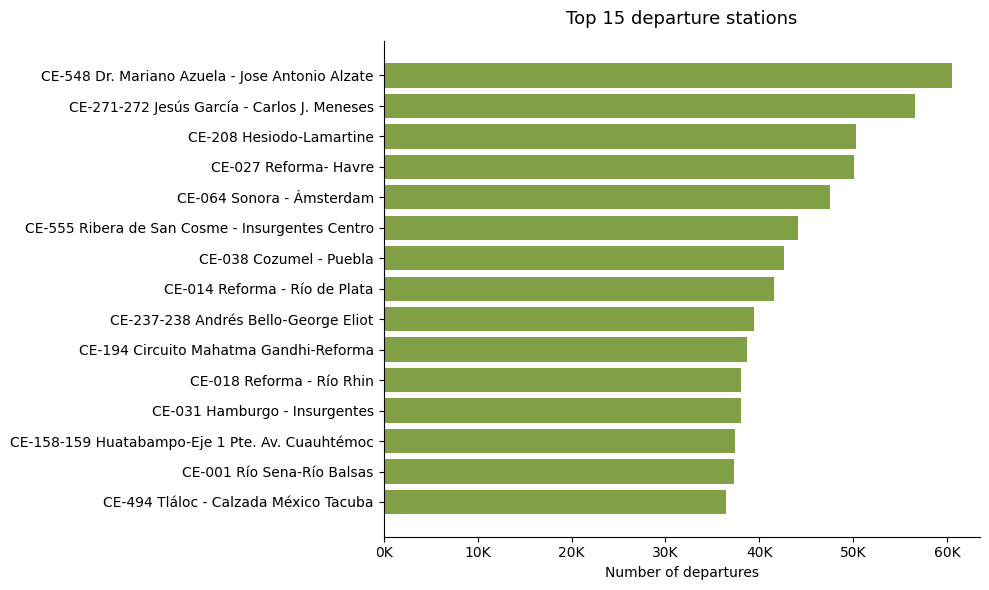

In [19]:
top_departures = (ecobici_clean
                  .groupby(['departure_station_id', 'departure_station_name'])
                  .size()
                  .reset_index(name='total_departures')
                  .sort_values('total_departures', ascending=False)
                  .head(15))

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_departures['departure_station_name'],
        top_departures['total_departures'],
        color='olivedrab', edgecolor='none', alpha=0.85)

ax.set_title('Top 15 departure stations', fontsize=13, pad=12)
ax.set_xlabel('Number of departures')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Top arrival stations

The stations with the highest number of trip arrivals indicate where bikes tend to accumulate over time.

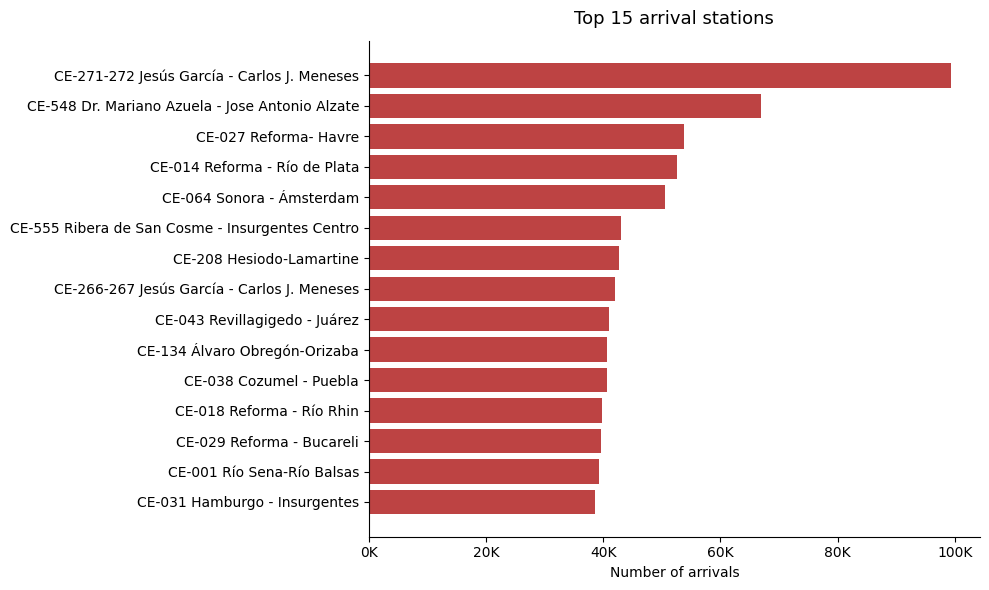

In [20]:
## Top arrival stations

top_arrivals = (ecobici_clean
                .groupby(['arrival_station_id', 'arrival_station_name'])
                .size()
                .reset_index(name='total_arrivals')
                .sort_values('total_arrivals', ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_arrivals['arrival_station_name'],
        top_arrivals['total_arrivals'],
        color='firebrick', edgecolor='none', alpha=0.85)

ax.set_title('Top 15 arrival stations', fontsize=13, pad=12)
ax.set_xlabel('Number of arrivals')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Demand by municipality

Aggregating demand at the municipality (alcaldía) level reveals which areas of the city concentrate the most activity.

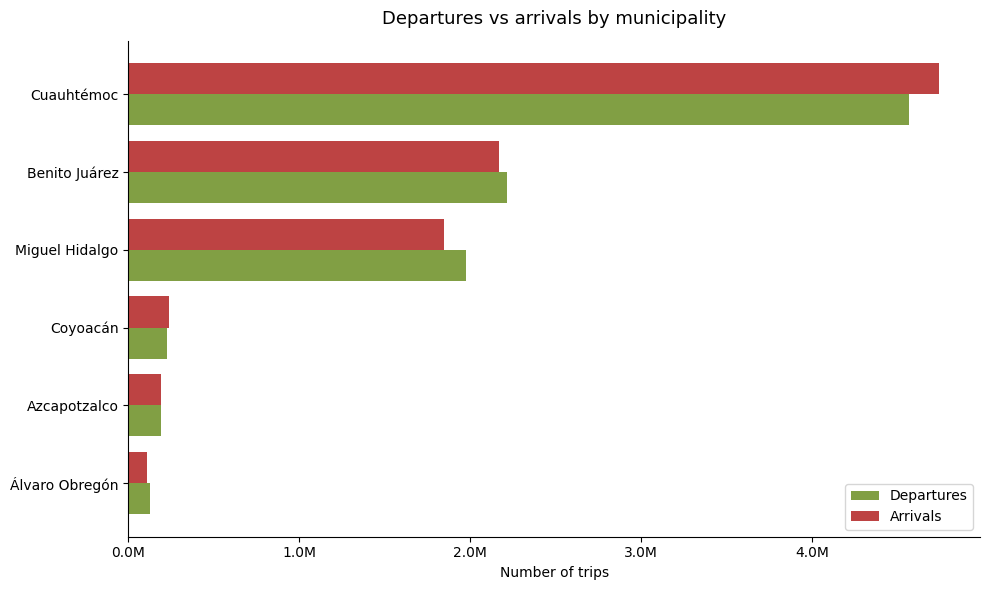

In [21]:
## Demand by municipality

muni_departures = (ecobici_clean
                   .groupby('departure_municipality')
                   .size()
                   .reset_index(name='departures'))

muni_arrivals = (ecobici_clean
                 .groupby('arrival_municipality')
                 .size()
                 .reset_index(name='arrivals'))

muni = (muni_departures
        .merge(muni_arrivals,
               left_on='departure_municipality',
               right_on='arrival_municipality')
        .rename(columns={'departure_municipality': 'municipality'})
        .drop(columns='arrival_municipality')
        .sort_values('departures', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(muni))
width = 0.4

ax.barh([i + width/2 for i in x], muni['departures'],
        width, label='Departures', color='olivedrab', alpha=0.85)
ax.barh([i - width/2 for i in x], muni['arrivals'],
        width, label='Arrivals', color='firebrick', alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(muni['municipality'])
ax.set_title('Departures vs arrivals by municipality', fontsize=13, pad=12)
ax.set_xlabel('Number of trips')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

### 4. Most Popular Routes

A route is defined as a unique origin-destination pair: the combination of a departure station and an arrival station. Identifying the most frequently used routes helps understand dominant travel corridors within the system.

#### Top origin-destination pairs

The following chart shows the 15 most frequently used station-to-station routes across the entire six-month period.

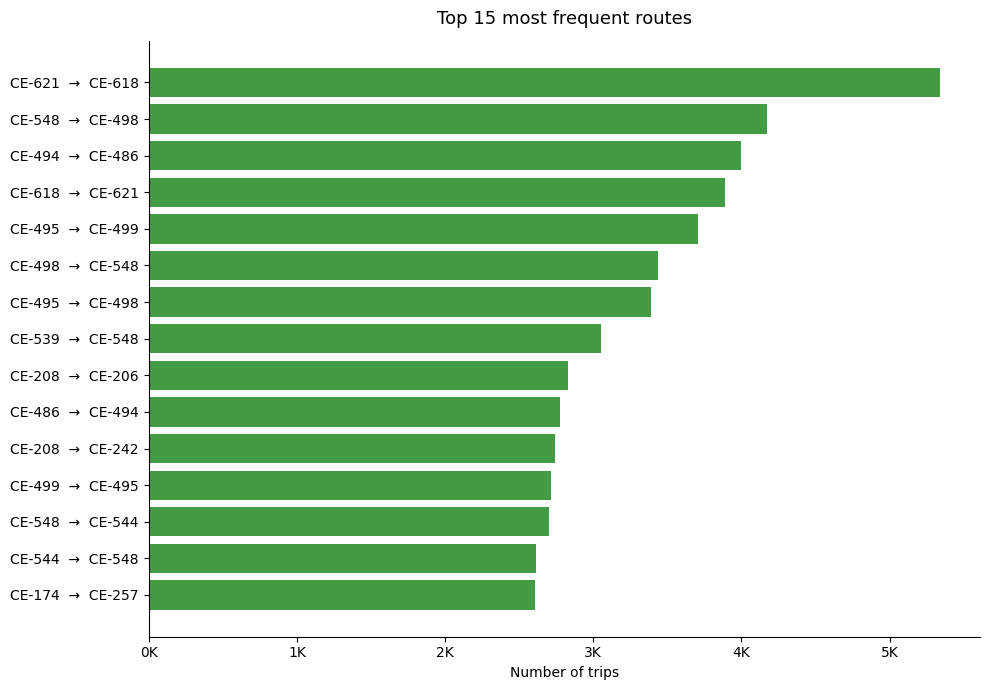

In [22]:
## Top OD pairs

routes = (ecobici_clean
          .groupby(['departure_station_id', 'arrival_station_id'])
          .size()
          .reset_index(name='total_trips')
          .sort_values('total_trips', ascending=False)
          .head(15))

routes['route'] = 'CE-' + routes['departure_station_id'] + '  →  ' + 'CE-' + routes['arrival_station_id']

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(routes['route'], routes['total_trips'],
        color='forestgreen', edgecolor='none', alpha=0.85)

ax.set_title('Top 15 most frequent routes', fontsize=13, pad=12)
ax.set_xlabel('Number of trips')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Weekday vs weekend top routes

The most popular routes may differ depending on the day type. 

Commuter-driven routes tend to dominate on weekdays, while weekend routes may reflect more recreational travel patterns.

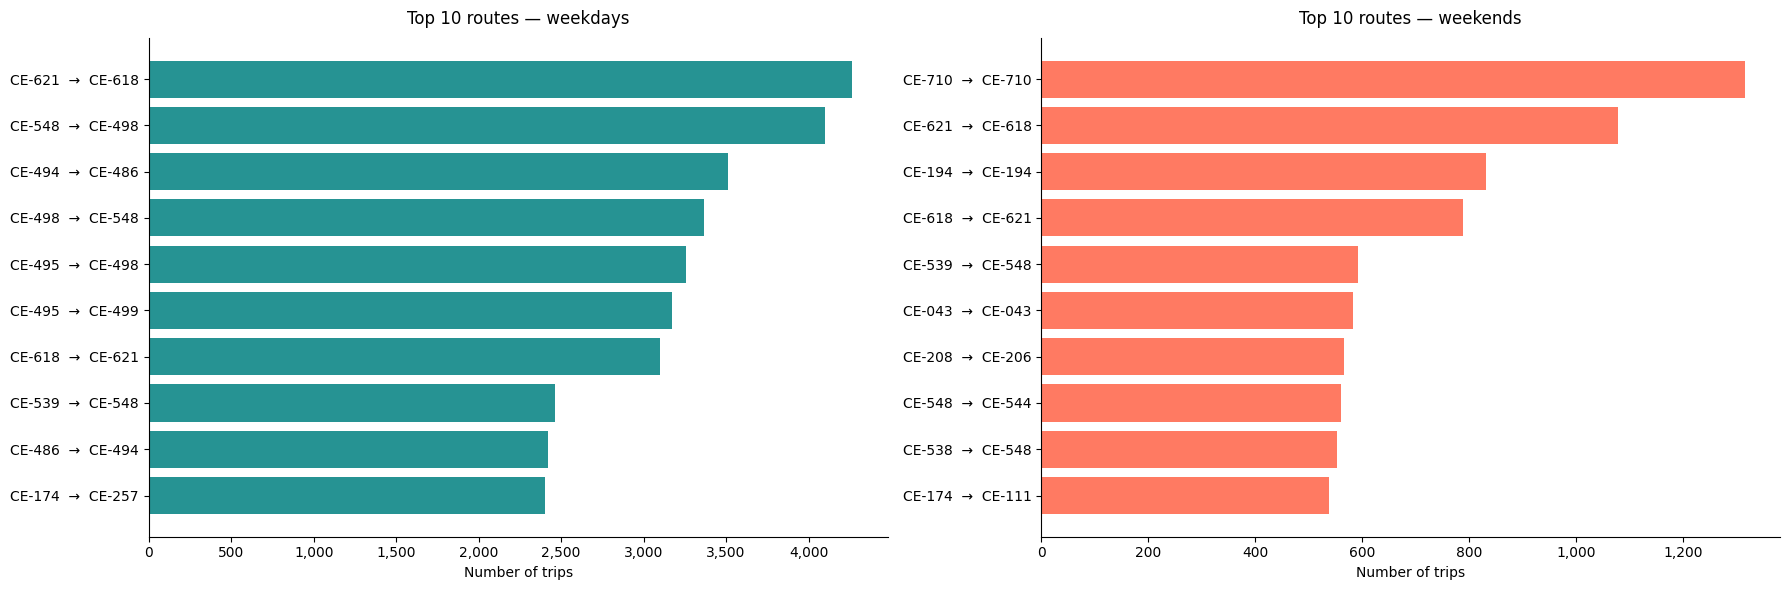

In [23]:
## Top routes weekday vs weekend

top_routes_wd = (ecobici_clean[ecobici_clean['is_weekend'] == False]
                 .groupby(['departure_station_id', 'arrival_station_id'])
                 .size()
                 .reset_index(name='total_trips')
                 .sort_values('total_trips', ascending=False)
                 .head(10))

top_routes_we = (ecobici_clean[ecobici_clean['is_weekend'] == True]
                 .groupby(['departure_station_id', 'arrival_station_id'])
                 .size()
                 .reset_index(name='total_trips')
                 .sort_values('total_trips', ascending=False)
                 .head(10))

top_routes_wd['route'] = 'CE-' + top_routes_wd['departure_station_id'] + '  →  CE-' + top_routes_wd['arrival_station_id']
top_routes_we['route'] = 'CE-' + top_routes_we['departure_station_id'] + '  →  CE-' + top_routes_we['arrival_station_id']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_routes_wd['route'], top_routes_wd['total_trips'],
             color='teal', edgecolor='none', alpha=0.85)
axes[0].set_title('Top 10 routes — weekdays', fontsize=12, pad=10)
axes[0].set_xlabel('Number of trips')
axes[0].xaxis.set_major_formatter( plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].invert_yaxis()

axes[1].barh(top_routes_we['route'], top_routes_we['total_trips'],
             color='tomato', edgecolor='none', alpha=0.85)
axes[1].set_title('Top 10 routes — weekends', fontsize=12, pad=10)
axes[1].set_xlabel('Number of trips')
axes[1].xaxis.set_major_formatter( plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Route concentration

How concentrated is demand across routes? The following analysis shows what percentage of total trips is accounted for by the top routes, revealing whether demand is spread evenly or heavily concentrated in a few corridors.

In [24]:
## Route concentration

all_routes = (ecobici_clean
              .groupby(['departure_station_name', 'arrival_station_name'])
              .size()
              .reset_index(name='total_trips')
              .sort_values('total_trips', ascending=False))

total_trips  = all_routes['total_trips'].sum()
all_routes['cumulative_pct'] = all_routes['total_trips'].cumsum() / total_trips * 100

top_10_pct  = all_routes.head(10)['total_trips'].sum()  / total_trips * 100
top_50_pct  = all_routes.head(50)['total_trips'].sum()  / total_trips * 100
top_100_pct = all_routes.head(100)['total_trips'].sum() / total_trips * 100

print(f"Total unique routes:               {len(all_routes):,}")
print(f"Top 10 routes account for:         {top_10_pct:.1f}% of all trips")
print(f"Top 50 routes account for:         {top_50_pct:.1f}% of all trips")
print(f"Top 100 routes account for:        {top_100_pct:.1f}% of all trips")


Total unique routes:               320,325
Top 10 routes account for:         0.4% of all trips
Top 50 routes account for:         1.3% of all trips
Top 100 routes account for:        2.2% of all trips


With over 320,000 unique origin-destination pairs, demand is highly dispersed across the network. The top 100 routes account for only 2.2% of all trips, confirming that no single corridor dominates usage.

This finding is operationally significant: redistribution strategies cannot rely on optimizing specific routes. Instead, the focus should shift to **station-level patterns**, identifying which stations consistently lose or accumulate bikes over time, regardless of where those trips originate or end.

### 5. Station Imbalance

A station is considered imbalanced when its number of departures and arrivals differ significantly over time. Stations that consistently lose bikes (more departures than arrivals) risk running empty, while stations that accumulate bikes (more arrivals than departures) may run out of docking space.

To quantify this, we calculate the **net flow** for each station:

> `net_flow = total_arrivals - total_departures`

- A **negative net flow** means the station loses bikes over time: redistribution needed
- A **positive net flow** means the station accumulates bikes over time: bikes should be moved out
- A **net flow near zero** indicates a balanced station

In [25]:
## Calculate net flow

departures = (ecobici_clean
              .groupby(['departure_station_id', 'departure_station_name', 
                        'departure_municipality'])
              .size()
              .reset_index(name='total_departures')
              .rename(columns={
                  'departure_station_id'  : 'station_id',
                  'departure_station_name': 'station_name',
                  'departure_municipality': 'municipality'
              }))

arrivals = (ecobici_clean
            .groupby(['arrival_station_id', 'arrival_station_name',
                      'arrival_municipality'])
            .size()
            .reset_index(name='total_arrivals')
            .rename(columns={
                'arrival_station_id'  : 'station_id',
                'arrival_station_name': 'station_name',
                'arrival_municipality': 'municipality'
            }))

station_balance = (departures
                   .merge(arrivals, on=['station_id', 'station_name', 'municipality'], 
                          how='outer')
                   .fillna(0))

station_balance['net_flow']      = (station_balance['total_arrivals'] 
                                    - station_balance['total_departures'])
station_balance['total_trips']   = (station_balance['total_arrivals'] 
                                    + station_balance['total_departures'])
station_balance['imbalance_rate'] = (station_balance['net_flow'] 
                                     / station_balance['total_trips'])

station_balance = station_balance.sort_values('net_flow')

print(f"Stations analyzed: {len(station_balance):,}")
print(f"\nBalance summary:")
print(f"Stations losing bikes (net_flow < 0): {(station_balance['net_flow'] < 0).sum():,}")
print(f"Stations gaining bikes (net_flow > 0): {(station_balance['net_flow'] > 0).sum():,}")
print(f"Balanced stations (net_flow = 0): {(station_balance['net_flow'] == 0).sum():,}")

Stations analyzed: 677

Balance summary:
Stations losing bikes (net_flow < 0): 369
Stations gaining bikes (net_flow > 0): 308
Balanced stations (net_flow = 0): 0


#### Stations with the highest bike deficit

These stations consistently have more departures than arrivals. They are the most likely to run out of bikes and require priority restocking.

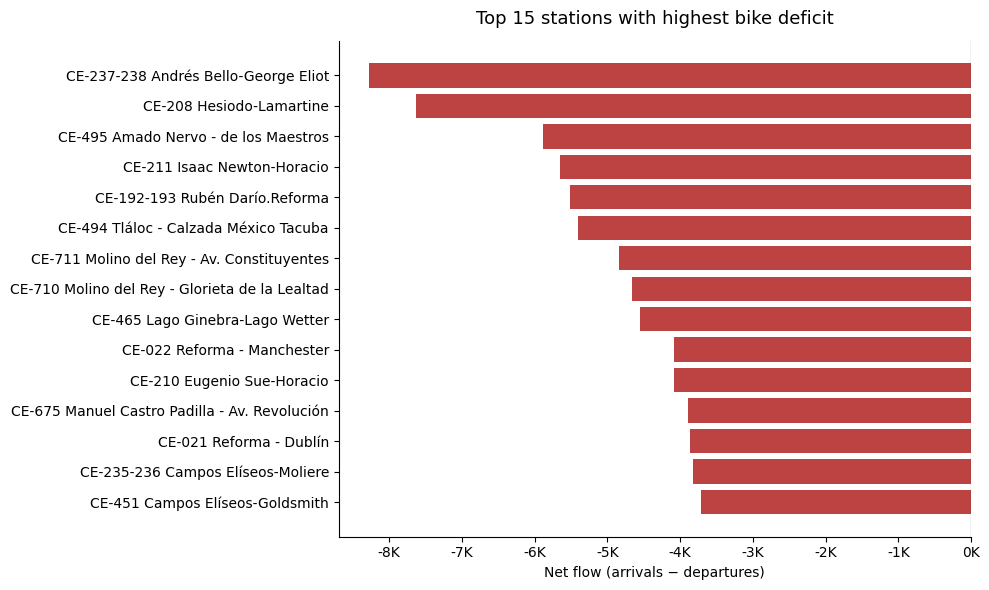

In [26]:
## Top deficit stations

top_deficit = station_balance.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_deficit['station_name'], top_deficit['net_flow'],
        color='firebrick', edgecolor='none', alpha=0.85)

ax.set_title('Top 15 stations with highest bike deficit', fontsize=13, pad=12)
ax.set_xlabel('Net flow (arrivals − departures)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Stations with the highest bike surplus

These stations consistently receive more bikes than they send out. They accumulate inventory over time and are candidates for bike pickup during redistribution operations.

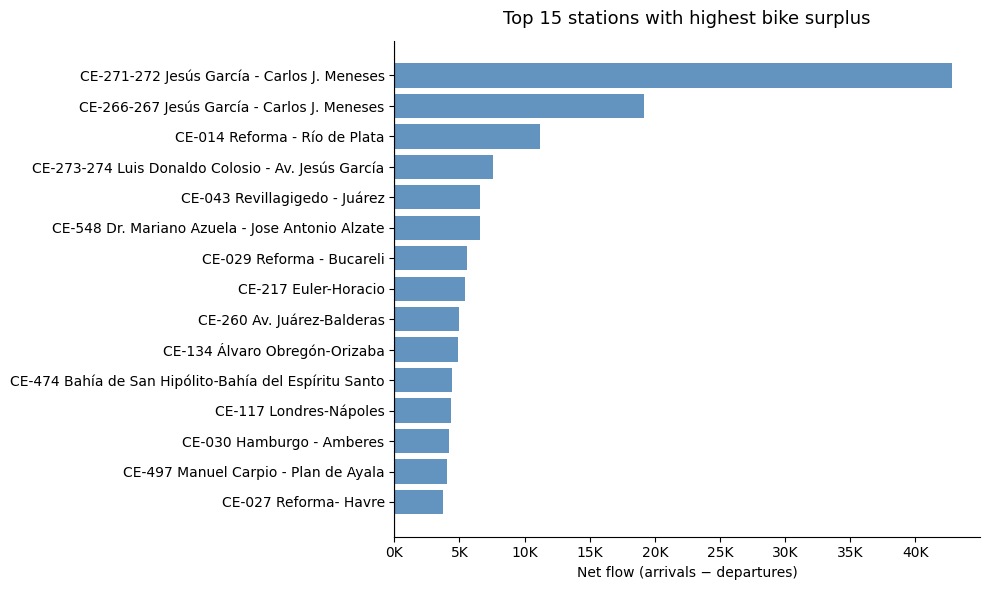

In [27]:
## Top surplus statios

top_surplus = station_balance.tail(15).sort_values('net_flow', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_surplus['station_name'], top_surplus['net_flow'],
        color='steelblue', edgecolor='none', alpha=0.85)

ax.set_title('Top 15 stations with highest bike surplus', fontsize=13, pad=12)
ax.set_xlabel('Net flow (arrivals − departures)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Imbalance distribution across all stations

The following histogram shows how net flow is distributed across the entire network, revealing whether most stations are roughly balanced or whether imbalance is widespread.

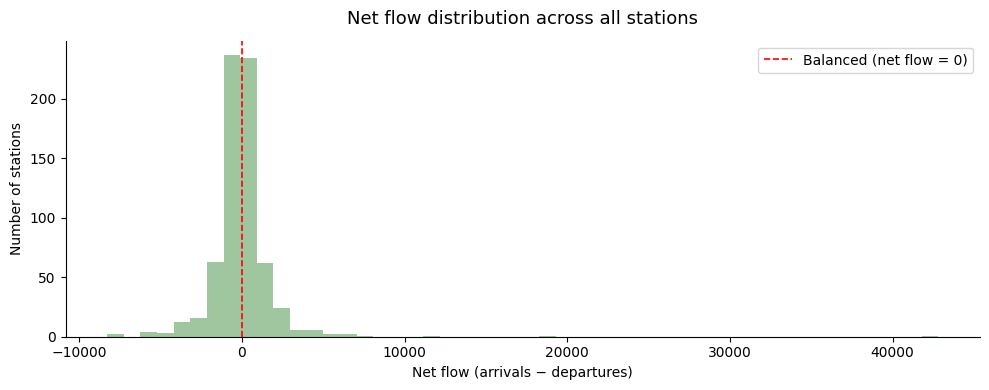

In [28]:
## Imbalance distribution

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(station_balance['net_flow'], bins=50,
        color='darkseagreen', edgecolor='none', alpha=0.85)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Balanced (net flow = 0)')
ax.set_title('Net flow distribution across all stations', fontsize=13, pad=12)
ax.set_xlabel('Net flow (arrivals − departures)')
ax.set_ylabel('Number of stations')
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

#### Imbalance by municipality

Aggregating net flow at the municipality level reveals whether certain areas of the city systematically lose or accumulate bikes.

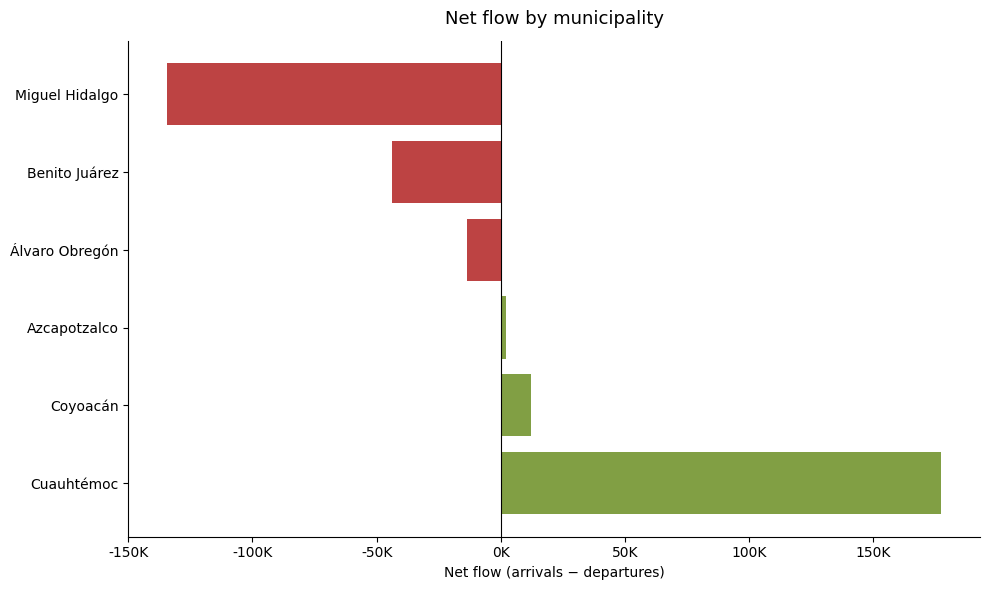

In [29]:
## Imbalance by municipality

muni_balance = (station_balance
                .groupby('municipality')
                .agg(
                    total_departures=('total_departures', 'sum'),
                    total_arrivals  =('total_arrivals',   'sum'),
                    net_flow        =('net_flow',         'sum')
                )
                .reset_index()
                .sort_values('net_flow'))

colors = ['firebrick' if x < 0 else 'olivedrab' for x in muni_balance['net_flow']]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(muni_balance['municipality'], muni_balance['net_flow'],
        color=colors, edgecolor='none', alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Net flow by municipality', fontsize=13, pad=12)
ax.set_xlabel('Net flow (arrivals − departures)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.invert_yaxis()

sns.despine()
plt.tight_layout()
plt.show()

#### Key imbalance findings

Two stations stand out as the most extreme cases in the network:

| | Station | Municipality | Departures | Arrivals | Net flow |
|---|---|---|---|---|---|
| Highest surplus | CE-271-272 Jesús García - Carlos J. Meneses | Cuauhtémoc | 56,532 | 99,348 | +42,816 |
| Highest deficit | CE-237-238 Andrés Bello - George Eliot | Miguel Hidalgo | 39,394 | 31,113 | −8,281 |

The surplus at Jesús García / Carlos J. Meneses is over 5× larger in magnitude than the deficit at Andrés Bello / George Eliot. This asymmetry suggests that bike accumulation is highly concentrated in a few stations, while deficits are more evenly distributed across the network.

This has a direct operational implication: **a small number of high-surplus stations can serve as redistribution hubs**, supplying bikes to a larger number of moderate-deficit stations.

### 6. Temporal Imbalance

Knowing which stations are imbalanced is only part of the picture. To support operational decisions, we need to understand *when* those 
imbalances occur. This section examines how net flow evolves throughout the day and across day types, focusing on the stations identified as the most critical in the previous section.

#### Hourly net flow across the network

Aggregating net flow by hour of day across all stations reveals when the system as a whole experiences the most pronounced imbalances.

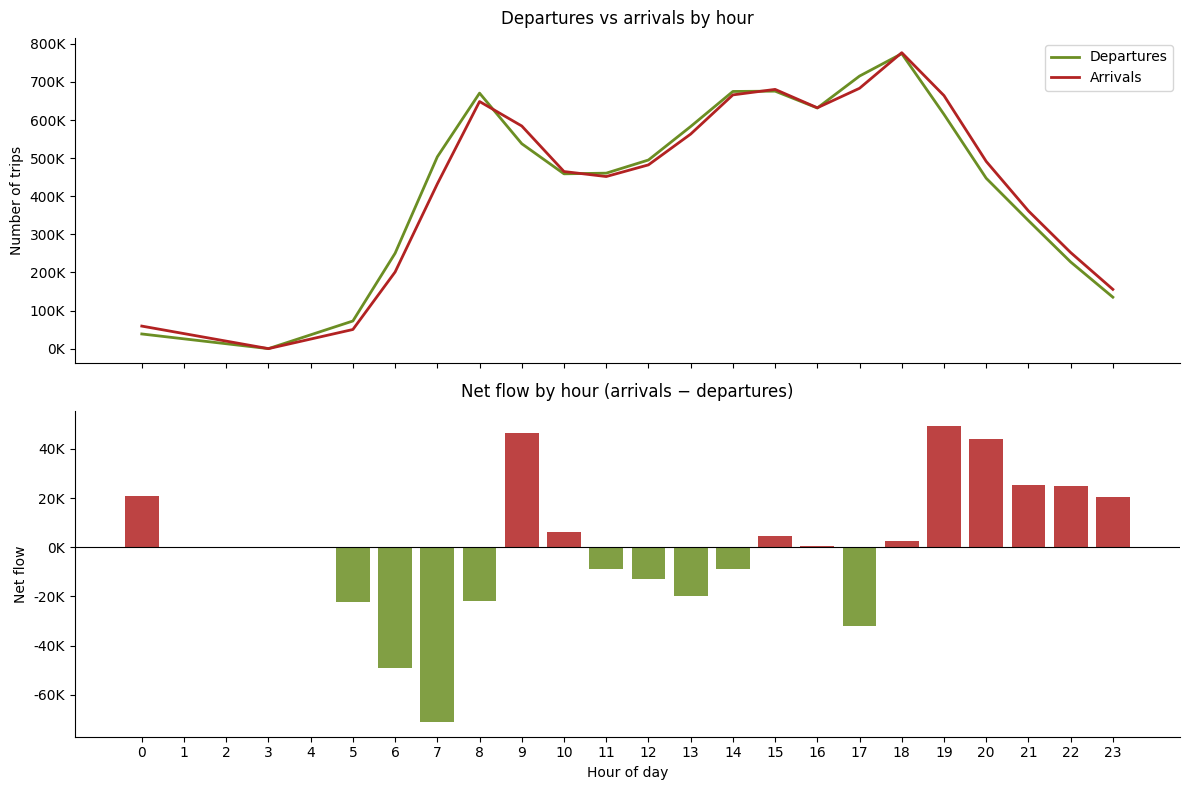

In [30]:
## Hourly net flow

hourly_departures = (ecobici_clean
                     .groupby('hour')
                     .size()
                     .reset_index(name='departures'))

hourly_arrivals = (ecobici_clean
                   .assign(hour=ecobici_clean['arrival_datetime'].dt.hour)
                   .groupby('hour')
                   .size()
                   .reset_index(name='arrivals'))

hourly_flow = (hourly_departures
               .merge(hourly_arrivals, on='hour')
               .assign(net_flow=lambda x: x['arrivals'] - x['departures']))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Departures vs arrivals
axes[0].plot(hourly_flow['hour'], hourly_flow['departures'],
             color='olivedrab', linewidth=2, label='Departures')
axes[0].plot(hourly_flow['hour'], hourly_flow['arrivals'],
             color='firebrick', linewidth=2, label='Arrivals')
axes[0].set_title('Departures vs arrivals by hour', fontsize=12, pad=10)
axes[0].set_ylabel('Number of trips')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend()

# Net flow
axes[1].bar(hourly_flow['hour'], hourly_flow['net_flow'],
            color=['firebrick' if x >= 0 else 'olivedrab' for x in hourly_flow['net_flow']],
            edgecolor='none', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Net flow by hour (arrivals − departures)', fontsize=12, pad=10)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Net flow')
axes[1].set_xticks(range(0, 24))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

sns.despine()
plt.tight_layout()
plt.show()

#### Hourly net flow — weekday vs weekend

The timing of imbalances may differ significantly between working days and weekends. Weekday commuter patterns typically generate sharp morning and evening peaks, while weekend demand tends to be more gradual and evenly distributed.

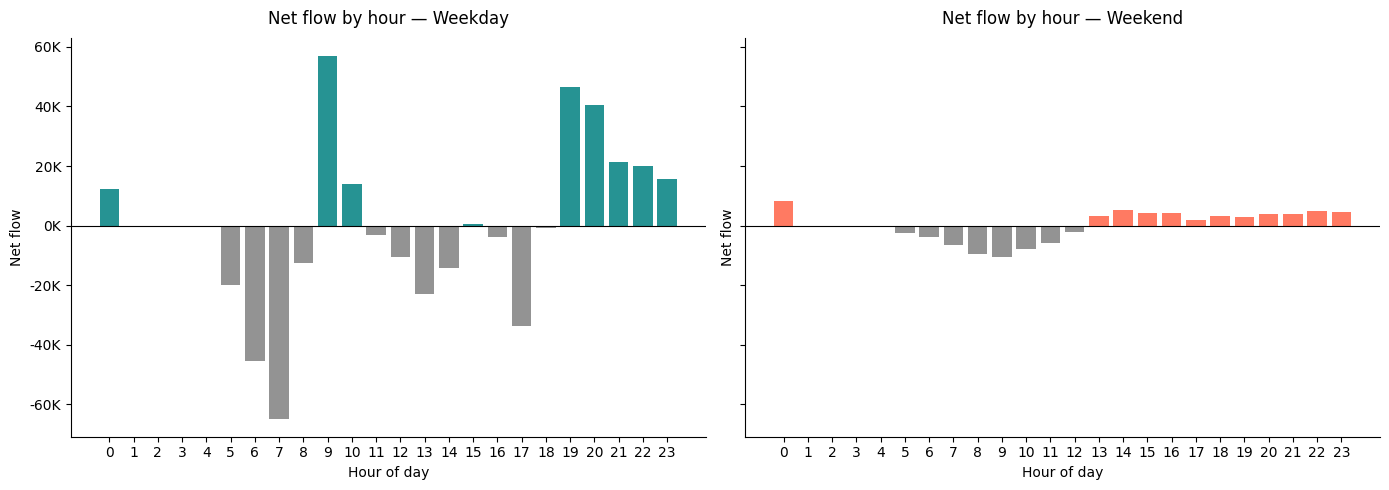

In [31]:
hourly_dep_type = (ecobici_clean
                   .groupby(['hour', 'is_weekend'])
                   .size()
                   .reset_index(name='departures'))

hourly_arr_type = (ecobici_clean
                   .assign(
                       hour=ecobici_clean['arrival_datetime'].dt.hour,
                       is_weekend=ecobici_clean['arrival_datetime'].dt.dayofweek.isin([5, 6])
                   )
                   .groupby(['hour', 'is_weekend'])
                   .size()
                   .reset_index(name='arrivals'))

hourly_flow_type = (hourly_dep_type
                    .merge(hourly_arr_type, on=['hour', 'is_weekend'])
                    .assign(net_flow=lambda x: x['arrivals'] - x['departures']))

hourly_flow_type['day_type'] = hourly_flow_type['is_weekend'].map(
    {False: 'Weekday', True: 'Weekend'}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, day_type, color in zip(axes, 
                                ['Weekday', 'Weekend'], 
                                ['teal', 'tomato']):
    subset = hourly_flow_type[hourly_flow_type['day_type'] == day_type]
    ax.bar(subset['hour'], subset['net_flow'],
           color=[color if x >= 0 else 'gray' for x in subset['net_flow']],
           edgecolor='none', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Net flow by hour — {day_type}', fontsize=12, pad=10)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Net flow')
    ax.set_xticks(range(0, 24))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

sns.despine()
plt.tight_layout()
plt.show()

#### Temporal imbalance at critical stations

Zooming into the stations with the highest deficit and surplus identified in the previous section, we examine how their net flow evolves hour by hour, revealing the specific time windows when redistribution would have the most impact.

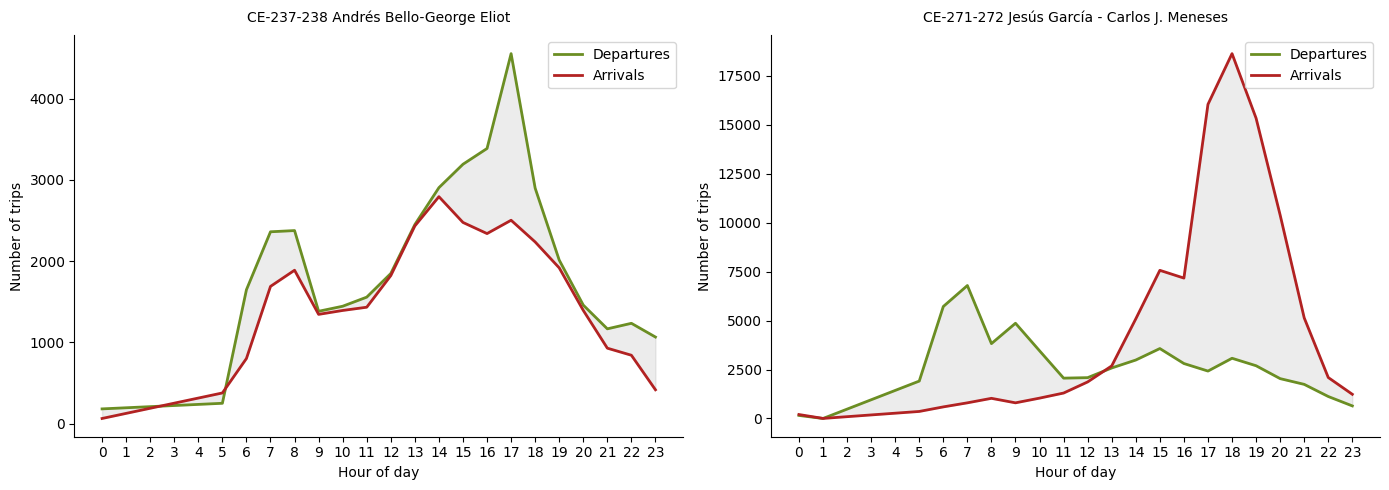

In [32]:
## Hourly net flow at critical stations

critical_stations = [
    'CE-237-238 Andrés Bello-George Eliot',      # highest deficit
    'CE-271-272 Jesús García - Carlos J. Meneses' # highest surplus
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, station in zip(axes, critical_stations):
    dep = (ecobici_clean[ecobici_clean['departure_station_name'] == station]
           .groupby('hour')
           .size()
           .reset_index(name='departures'))

    arr = (ecobici_clean[ecobici_clean['arrival_station_name'] == station]
           .assign(hour=ecobici_clean[
               ecobici_clean['arrival_station_name'] == station
           ]['arrival_datetime'].dt.hour)
           .groupby('hour')
           .size()
           .reset_index(name='arrivals'))

    flow = (dep.merge(arr, on='hour', how='outer')
               .fillna(0)
               .assign(net_flow=lambda x: x['arrivals'] - x['departures']))

    ax.plot(flow['hour'], flow['departures'],
            color='olivedrab', linewidth=2, label='Departures')
    ax.plot(flow['hour'], flow['arrivals'],
            color='firebrick', linewidth=2, label='Arrivals')
    ax.fill_between(flow['hour'],
                    flow['departures'], flow['arrivals'],
                    alpha=0.15, color='gray')

    ax.set_title(station, fontsize=10, pad=10)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Number of trips')
    ax.set_xticks(range(0, 24))
    ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

#### Monthly imbalance trend

Finally, we examine whether imbalance patterns shift across months, identifying whether certain periods of the year generate more pronounced redistribution needs.

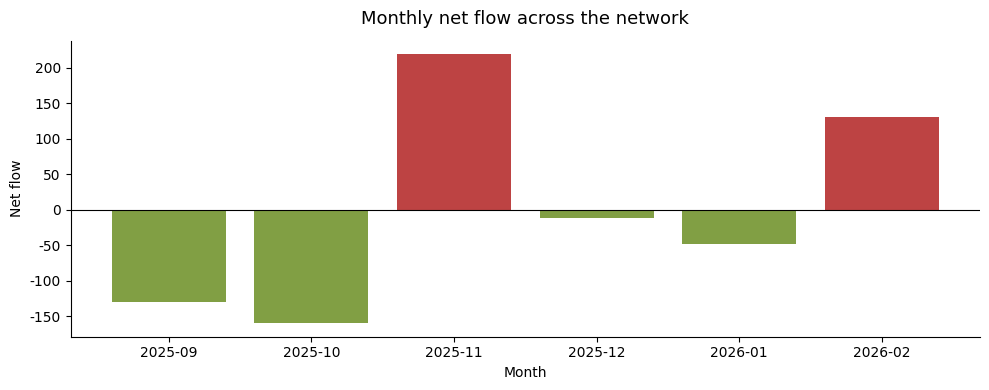

In [33]:
## Monthlu net flow trend

monthly_dep = (ecobici_clean
               .groupby('month')
               .size()
               .reset_index(name='departures'))

monthly_arr = (ecobici_clean
               .assign(month=ecobici_clean['arrival_datetime'].dt.to_period('M'))
               .groupby('month')
               .size()
               .reset_index(name='arrivals'))

monthly_flow = (monthly_dep
                .merge(monthly_arr, on='month')
                .assign(net_flow=lambda x: x['arrivals'] - x['departures']))

monthly_flow['month_str'] = monthly_flow['month'].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(monthly_flow['month_str'], monthly_flow['net_flow'],
       color=['firebrick' if x >= 0 else 'olivedrab' for x in monthly_flow['net_flow']],
       edgecolor='none', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly net flow across the network', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Net flow')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.despine()
plt.tight_layout()
plt.show()

## Key Findings & Recommendations

This section synthesizes the main findings from the analysis and translates them into actionable recommendations for ECOBICI's operations team.

### Key Findings

**1. Demand is heavily concentrated in weekday commuting hours**

Trip activity follows a clear bimodal pattern on weekdays, with peaks at 8am and 18pm. Tuesday, Wednesday and Thursday are the highest-demand days (~1.5M trips each), while weekend demand is approximately 40% lower and follows a single smooth peak around 1–2pm. This confirms that the system is used predominantly as a commuting tool rather than a recreational one.

**2. The network is geographically polarized**

Over 80% of all activity is concentrated in Cuauhtémoc, which operates as the primary destination borough of the network. Miguel Hidalgo (net flow: ~ 125K) and Benito Juárez (~ 50K) function as origin boroughs (users depart from these residential and mixed-use areas toward Cuauhtémoc in the morning and return in the evening).

**3. Bike imbalance is widespread but asymmetric**

369 out of 677 stations (55%) show a negative net flow over the six-month period. However, the imbalance is not symmetric: surpluses are highly concentrated in a few stations (CE-271-272 Jesús García alone accounts for +42,816 net bikes), while deficits are spread more evenly across many stations with moderate losses. The vast majority of stations have a net flow close to zero.

**4. A small number of stations drive most of the imbalance**

CE-271-272 and CE-266-267 Jesús García - Carlos J. Meneses together 
accumulate ~62,000 net bikes over six months, making them the dominant 
redistribution hubs in the network. On the deficit side, CE-237-238 
Andrés Bello-George Eliot leads with −8,281, followed by a cluster 
of stations in the Reforma/Polanco corridor (Miguel Hidalgo).

**5. Imbalances are time-specific and predictable**

The most severe network-wide deficit occurs at 6–7am on weekdays 
(net flow: −60K at 7am), immediately before the morning commute peak. 
The system recovers by 8–9am (+57K) as bikes arrive at destination stations. 
A secondary deficit occurs at 17pm, followed by surplus accumulation from 
19–23pm. On weekends, imbalances are minimal and evenly distributed. 
Redistribution pressure is almost exclusively a weekday phenomenon.

**6. Route demand is highly dispersed**

With over 320,000 unique origin-destination pairs, no single route dominates 
usage. The top 100 routes account for only 2.2% of all trips. This confirms 
that redistribution strategies must focus on station-level patterns rather 
than specific corridors.

### Recommendations

Based on the findings above, the following operational recommendations 
are proposed for ECOBICI's redistribution team:


**1. Prioritize pre-dawn restocking of high-deficit stations**

The most critical redistribution window on weekdays is between 5–6am, 
before demand surges at 7–8am. Stations in the Reforma/Polanco corridor 
(particularly CE-237-238 Andrés Bello-George Eliot, CE-208 Hesiodo-Lamartine, 
and CE-495 Amado Nervo) should be prioritized for bike delivery before 
the morning peak. Restocking after 7am is largely ineffective, as demand 
is already at its highest.


**2. Use high-surplus stations as redistribution hubs**

CE-271-272 and CE-266-267 Jesús García - Carlos J. Meneses accumulate 
bikes at a rate that far exceeds any other station in the network. 
These stations should serve as primary pickup points for redistribution 
trucks, particularly during the 19–23pm window when surplus accumulation 
is at its highest and demand has dropped sufficiently to allow safe 
docking operations.


**3. Establish a Miguel Hidalgo - Cuauhtémoc redistribution corridor**

The data shows a clear and consistent directional flow: bikes migrate 
from Miguel Hidalgo and Benito Juárez toward Cuauhtémoc throughout the day. 
A dedicated redistribution route between these boroughs (moving bikes 
from Cuauhtémoc back to Miguel Hidalgo overnight) would address the 
structural imbalance that accumulates daily.


**4. Differentiate weekday and weekend operations**

Weekend imbalances are minimal and evenly distributed across the network. 
Redistribution resources should be concentrated on weekday operations, 
particularly Monday through Thursday. Weekend operations can follow a 
lighter maintenance schedule focused on capacity checks rather than 
active rebalancing.


**5. Monitor the Jesús García complex as a system indicator**

Given that CE-271-272 Jesús García alone represents over 5× the surplus 
of any deficit station, its occupancy level serves as a reliable proxy 
for overall network health. When this station approaches full capacity 
during evening hours, it signals that a redistribution cycle is needed 
across the broader Cuauhtémoc area. Real-time monitoring of this station 
could trigger automated redistribution alerts.

### Conclusion

This analysis of 9.4 million ECOBICI trips (September 2025 – February 2026) 
demonstrates that bike distribution imbalances in the network are not random, they are structural, predictable, and time-specific.

The system follows a consistent daily cycle: bikes flow from residential 
areas (Miguel Hidalgo, Benito Juárez) toward the city center (Cuauhtémoc) 
during morning commute hours, and the reverse occurs in the evening. 
This cycle repeats Monday through Friday with high regularity, while 
weekends show a fundamentally different and far more balanced usage pattern.

The operational implication is clear: a relatively small number of 
targeted interventions (focused on the right stations, at the right times, 
on weekdays) could significantly improve bike availability across the 
entire network.

Further analysis could extend these findings by incorporating real-time 
occupancy data (via the GBFS API), weather variables, and station capacity 
to build a predictive model for proactive redistribution scheduling.